# DSBA6010 Final Project
## LLM-Based Privacy Attacks on Employee Performance Data

**Dataset:** [IBM HR Analytics Employee Attrition & Performance](https://www.kaggle.com/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset)  
**Project Overview:**  
This notebook investigates the privacy risks of sharing employee data in the age of Large Language Models (LLMs). We:
1. Load and explore the IBM HR Analytics dataset
2. Create a binary target: **High Performer** (based on PerformanceRating = 4)
3. Apply Differential Privacy (DP) at multiple epsilon levels
4. Assess utility (model accuracy) after privatization
5. Attack the privatized dataset using Membership Inference and Attribute Inference attacks

**References:**
- Liu et al. (2025) — Evaluating LLM-based Personal Information Extraction and Countermeasures. USENIX Security.
- Staab et al. (2024) — Beyond Memorization: Violating Privacy via Inference with LLMs. ICLR.
- Jayaraman & Evans (2022) — Are Attribute Inference Attacks Just Imputation? CCS.
- Kandpal et al. (2024) — User Inference Attacks on Large Language Models. EMNLP.
- Cirillo et al. (2025) — Augmenting Anonymized Data with AI. arXiv.
- Yan et al. (2025) — Stop Tracking Me! Proactive Defense Against Attribute Inference Attacks. arXiv.

## 0. Install Dependencies

In [1]:
# Run this cell once to install required packages
!pip install pandas numpy matplotlib seaborn scikit-learn diffprivlib kaggle

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.9/176.9 kB 9.9 MB/s eta 0:00:00


## 1. Setup & Data Loading

**Option A:** Download via Kaggle API (recommended)  
**Option B:** Manual download — go to the [Kaggle page](https://www.kaggle.com/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset), download `WA_Fn-UseC_-HR-Employee-Attrition.csv`, and place it in the same folder as this notebook.

In [70]:
# Direct download from URL
import pandas as pd

# Direct URL to the dataset (hosted on GitHub)
URL = "https://raw.githubusercontent.com/IBM/employee-attrition-aif360/master/data/emp_attrition.csv"

# Alternative URL if the above doesn't work:
# URL = "https://raw.githubusercontent.com/abulbasar/data/master/WA_Fn-UseC_-HR-Employee-Attrition.csv"

print("Loading dataset from URL...")
df = pd.read_csv(URL)
print(f"Dataset loaded successfully! Shape: {df.shape}")

Loading dataset from URL...
Dataset loaded successfully! Shape: (1470, 35)


In [19]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display basic info
print(f"Dataset shape: {df.shape}")
print(f"\nColumns ({len(df.columns)}):")
print(list(df.columns))

Dataset shape: (1470, 35)

Columns (35):
['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


## 2. Exploratory Data Analysis (EDA)

In [9]:
# Basic info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [10]:
# Summary statistics for numeric columns
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,1470.0,36.923810,9.135373,18.0,30.00,36.0,43.00,60.0
DailyRate,1470.0,802.485714,403.509100,102.0,465.00,802.0,1157.00,1499.0
DistanceFromHome,1470.0,9.192517,8.106864,1.0,2.00,7.0,14.00,29.0
Education,1470.0,2.912925,1.024165,1.0,2.00,3.0,4.00,5.0
EmployeeCount,1470.0,1.000000,0.000000,1.0,1.00,1.0,1.00,1.0
EmployeeNumber,1470.0,1024.865306,602.024335,1.0,491.25,1020.5,1555.75,2068.0
EnvironmentSatisfaction,1470.0,2.721769,1.093082,1.0,2.00,3.0,4.00,4.0
HourlyRate,1470.0,65.891156,20.329428,30.0,48.00,66.0,83.75,100.0
JobInvolvement,1470.0,2.729932,0.711561,1.0,2.00,3.0,3.00,4.0
JobLevel,1470.0,2.063946,1.106940,1.0,1.00,2.0,3.00,5.0


In [71]:
drop_cols = ['DailyRate', 'EmployeeCount', 'EmployeeNumber', 'JobInvolvement', 'HourlyRate', 'MonthlyIncome', 'MonthlyRate', 'PercentSalaryHike', 'StandardHours', 'StockOptionLevel']
df.drop(columns=drop_cols, inplace=True)

In [46]:
# Check for missing values
missing = df.isnull().sum()
print("Missing values per column:")
print(missing[missing > 0] if missing.sum() > 0 else "None — dataset is complete.")

Missing values per column:
None — dataset is complete.


In [47]:
# Explore key variables in the dataset
print("Key dataset statistics:")
print(f"Total employees: {len(df)}")
print(f"\nDepartments: {df['Department'].nunique()}")
print(df['Department'].value_counts())
print(f"\nGender distribution:")
print(df['Gender'].value_counts())
print(f"\nAge range: {df['Age'].min()} - {df['Age'].max()} years")
print(f"Average age: {df['Age'].mean():.1f} years")

Key dataset statistics:
Total employees: 1470

Departments: 3
Department
Research & Development    961
Sales                     446
Human Resources            63
Name: count, dtype: int64

Gender distribution:
Gender
Male      882
Female    588
Name: count, dtype: int64

Age range: 18 - 60 years
Average age: 36.9 years


In [48]:
# Explore PerformanceRating values
print("PerformanceRating value counts:")
print(df['PerformanceRating'].value_counts().sort_index())
print(f"\nUnique values: {sorted(df['PerformanceRating'].unique())}")
print(f"Maximum PerformanceRating: {df['PerformanceRating'].max()}")
print(f"\nHigh Performers (max rating = {df['PerformanceRating'].max()}):")
high_performers = df['PerformanceRating'] == df['PerformanceRating'].max()
print(f"Count: {high_performers.sum()}")
print(f"Percentage: {high_performers.mean():.1%}")
print(f"\nTotal records: {len(df)}")

PerformanceRating value counts:
PerformanceRating
3    1244
4     226
Name: count, dtype: int64

Unique values: [np.int64(3), np.int64(4)]
Maximum PerformanceRating: 4

High Performers (max rating = 4):
Count: 226
Percentage: 15.4%

Total records: 1470


### ⚠️ Data Quality Note: PerformanceRating Values

**Documentation vs. Actual Data Mismatch:**
- **[Kaggle Documentation](https://www.kaggle.com/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset)** states: PerformanceRating ranges from 1-4
- **Actual data** contains: Only values 3 and 4

**Implications:**
1. **Missing values 1-2**: Either the dataset was filtered, or IBM's performance system only uses ratings 3-4
2. **Binary classification**: This simplifies the task to a 2-class problem (rating 3 vs. 4)
3. **Limited variability**: Reduces the complexity of predicting high performers
4. **Common in real datasets**: Many rating systems have restricted ranges in practice

**For this analysis:**
- We treat **rating 4 as "High Performer"** (15.4% of employees)
- We treat **rating 3 as "Not High Performer"** (84.6% of employees)
- This binary classification is appropriate for privacy attack demonstrations

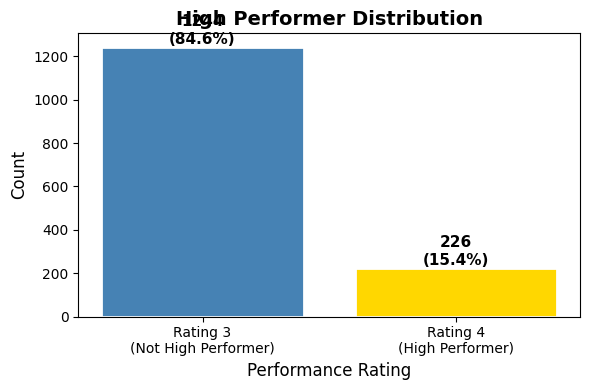

In [49]:
# Visualize High Performer distribution
high_performer_counts = df['PerformanceRating'].value_counts().sort_index()
labels = ['Rating 3\n(Not High Performer)', 'Rating 4\n(High Performer)']

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(labels, high_performer_counts.values, color=['steelblue', 'gold'], edgecolor='white', linewidth=2)
ax.set_title('High Performer Distribution', fontsize=14, fontweight='bold')
ax.set_ylabel('Count', fontsize=12)
ax.set_xlabel('Performance Rating', fontsize=12)

# Add count labels on bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}\n({height/len(df):.1%})',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

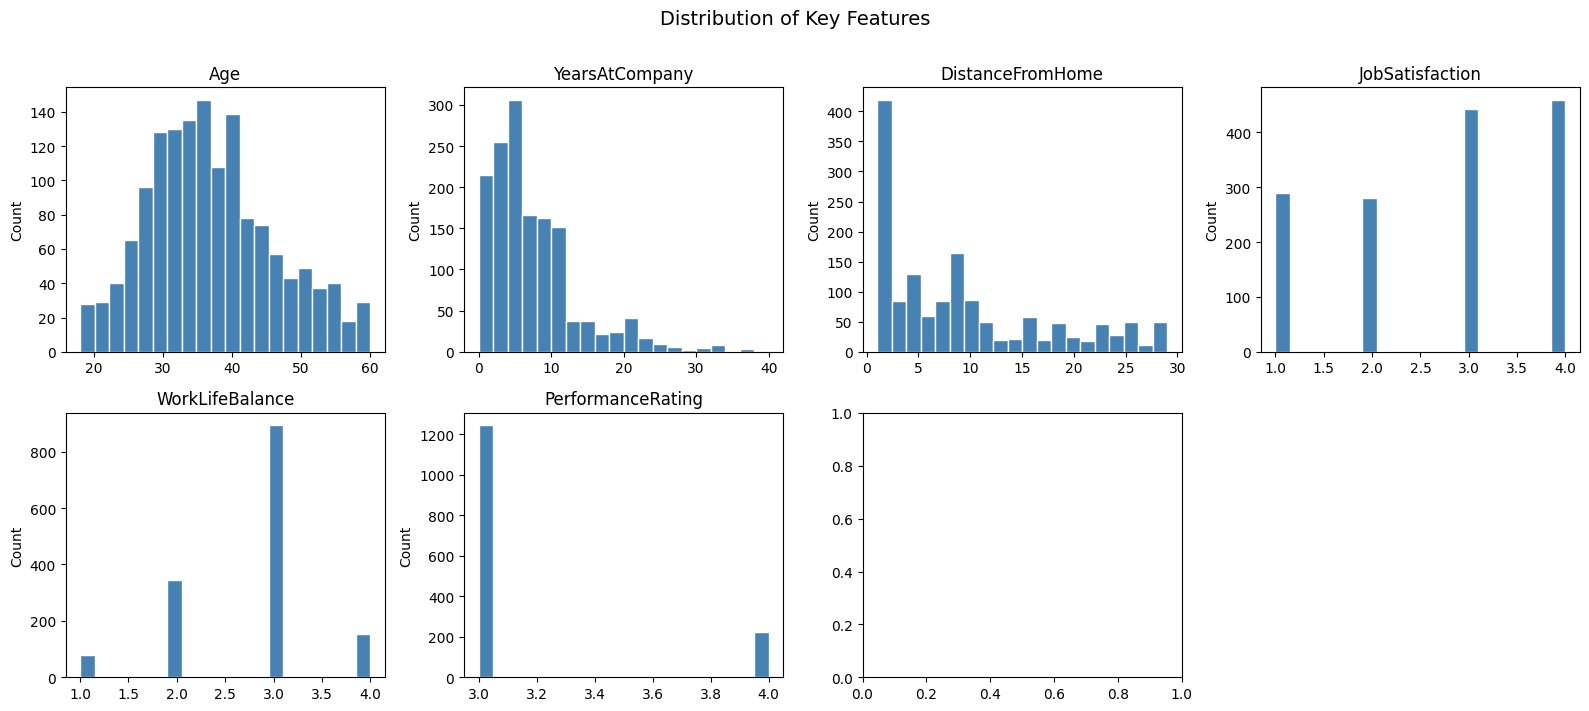

In [51]:
# Distribution of key numeric features
numeric_cols = ['Age', 'YearsAtCompany', 'DistanceFromHome',
                'JobSatisfaction', 'WorkLifeBalance', 'PerformanceRating']

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col], bins=20, color='steelblue', edgecolor='white')
    axes[i].set_title(col)
    axes[i].set_ylabel('Count')

# Hide unused subplot
axes[-1].set_visible(False)
plt.suptitle('Distribution of Key Features', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

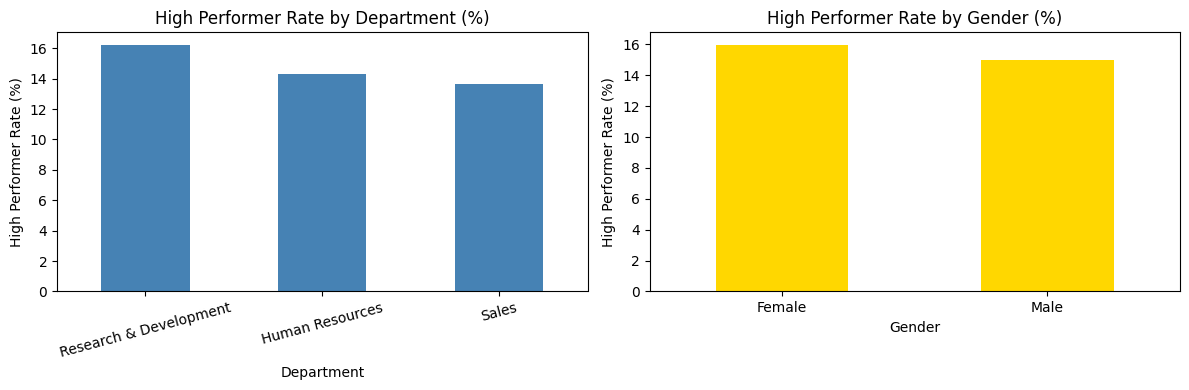

In [52]:
# High Performer Rate by Department and Gender
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# High Performer rate by Department
dept_hp = df.groupby('Department')['PerformanceRating'].apply(
    lambda x: (x == 4).mean() * 100
).sort_values(ascending=False)
dept_hp.plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('High Performer Rate by Department (%)')
axes[0].set_ylabel('High Performer Rate (%)')
axes[0].tick_params(axis='x', rotation=15)

# High Performer rate by Gender
gender_hp = df.groupby('Gender')['PerformanceRating'].apply(
    lambda x: (x == 4).mean() * 100
)
gender_hp.plot(kind='bar', ax=axes[1], color='gold')
axes[1].set_title('High Performer Rate by Gender (%)')
axes[1].set_ylabel('High Performer Rate (%)')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

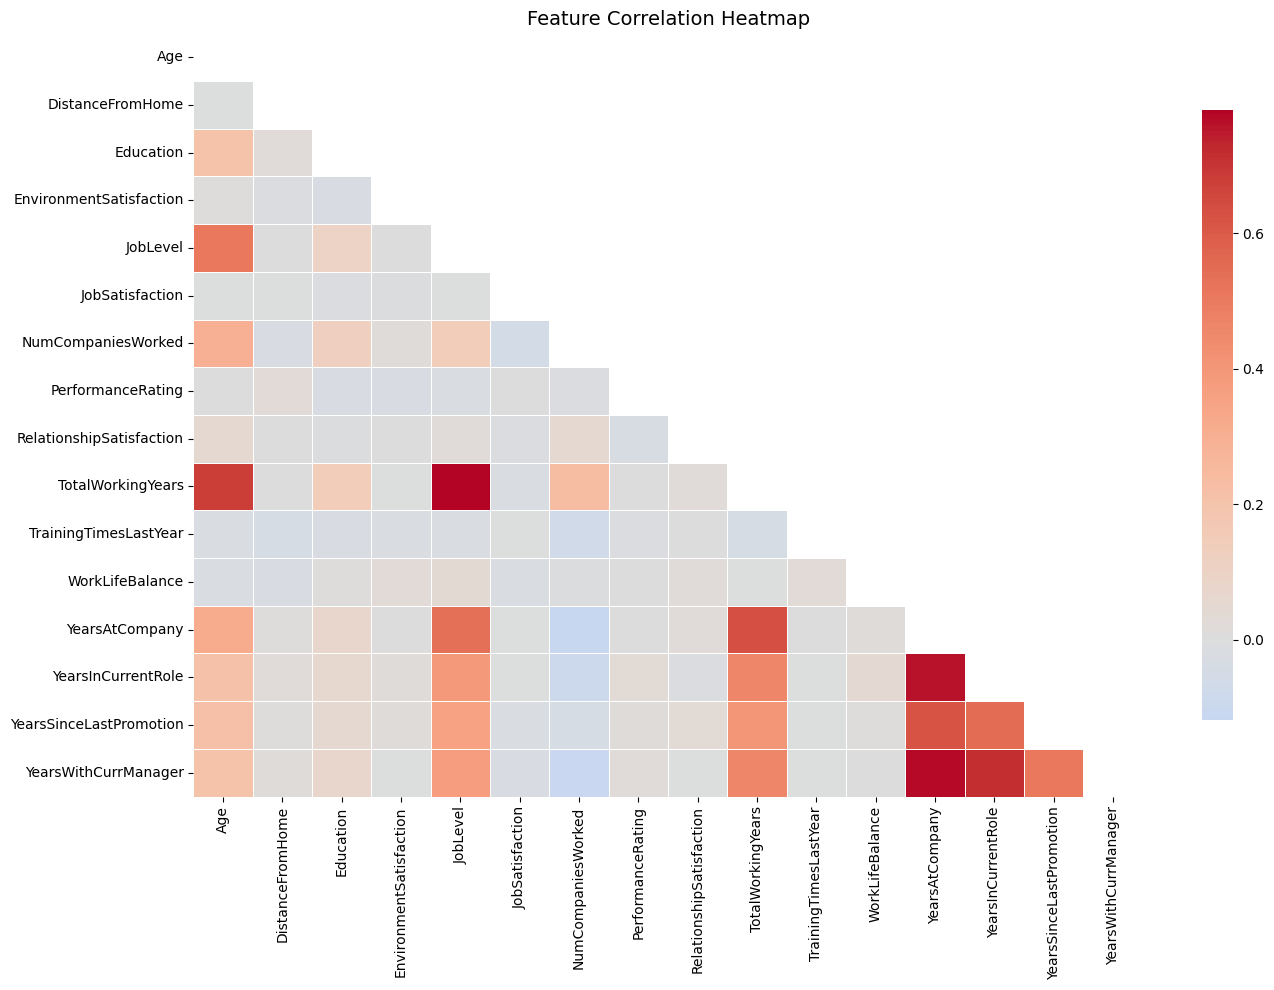

In [53]:
# Correlation heatmap (numeric features only)
numeric_df = df.select_dtypes(include=[np.number])

plt.figure(figsize=(14, 10))
corr = numeric_df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))  # hide upper triangle
sns.heatmap(corr, mask=mask, annot=False, cmap='coolwarm', center=0,
            linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.show()

## 3. Preprocessing

Create the **High Performer** target variable based on PerformanceRating (1 if rating = 4, 0 otherwise).  
Remove data leakage by dropping **PercentSalaryHike** (correlation: 0.78 with target).  
Encode categorical variables and split into train/test sets.  
This preprocessed dataset will serve as the **baseline** before any privatization.

In [55]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

df_processed = df.copy()

# Create High Performer target variable (1 if PerformanceRating = 4, else 0)
df_processed['HighPerformer'] = (df_processed['PerformanceRating'] == 4).astype(int)
print("Created target variable: HighPerformer")
print(f"High Performers: {df_processed['HighPerformer'].sum()} ({df_processed['HighPerformer'].mean():.1%})")
print(f"Non-High Performers: {(df_processed['HighPerformer']==0).sum()} ({(df_processed['HighPerformer']==0).mean():.1%})")

# Encode binary/categorical columns
le = LabelEncoder()
categorical_cols = df_processed.select_dtypes(include='object').columns.tolist()
print(f"\nEncoding categorical columns: {categorical_cols}")

for col in categorical_cols:
    df_processed[col] = le.fit_transform(df_processed[col])

# Features and target
X = df_processed.drop(columns=['HighPerformer', 'PerformanceRating'])  # Drop both target and raw rating
y = df_processed['HighPerformer']  # 0 = Not High Performer, 1 = High Performer

print(f"\nDropped PerformanceRating from features (used to create target)")

# Train/test split (stratified to preserve High Performer ratio)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\nTrain size: {X_train.shape[0]} | Test size: {X_test.shape[0]}")
print(f"Features: {X_train.shape[1]}")
print(f"High Performer rate (train): {y_train.mean():.1%}")

Created target variable: HighPerformer
High Performers: 226 (15.4%)
Non-High Performers: 1244 (84.6%)

Encoding categorical columns: ['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'Over18', 'OverTime']

Dropped PerformanceRating from features (used to create target)

Train size: 1176 | Test size: 294
Features: 24
High Performer rate (train): 15.4%


## 3.5 Multicollinearity Assessment (VIF)

**Variance Inflation Factor (VIF)** measures how much the variance of a regression coefficient is inflated due to multicollinearity with other predictors.

**Interpretation:**
- **VIF = 1**: No correlation with other features
- **VIF < 5**: Acceptable level of multicollinearity
- **VIF 5-10**: Moderate multicollinearity (monitor)
- **VIF > 10**: High multicollinearity (consider removal or dimensionality reduction)

In [56]:
# Calculate VIF for all features
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Use the scaled training data for VIF calculation
X_train_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)

# Calculate VIF for each feature
vif_data = pd.DataFrame()
vif_data["Feature"] = X_train.columns
vif_data["VIF"] = [variance_inflation_factor(X_train_df.values, i) 
                   for i in range(len(X_train.columns))]

# Sort by VIF value (descending)
vif_data = vif_data.sort_values('VIF', ascending=False).reset_index(drop=True)

print("="*70)
print("Variance Inflation Factor (VIF) Analysis")
print("="*70)
print(vif_data.to_string(index=False))
print("="*70)

# Identify features with high VIF
high_vif = vif_data[vif_data['VIF'] > 10]
moderate_vif = vif_data[(vif_data['VIF'] >= 5) & (vif_data['VIF'] <= 10)]
low_vif = vif_data[vif_data['VIF'] < 5]

print(f"\n📊 VIF Summary:")
print(f"   High multicollinearity (VIF > 10): {len(high_vif)} features")
print(f"   Moderate multicollinearity (5 ≤ VIF ≤ 10): {len(moderate_vif)} features")
print(f"   Low multicollinearity (VIF < 5): {len(low_vif)} features")

if len(high_vif) > 0:
    print(f"\n⚠️  Features with high VIF (>10):")
    for idx, row in high_vif.iterrows():
        print(f"   - {row['Feature']}: {row['VIF']:.2f}")
else:
    print(f"\n✓ No features with severe multicollinearity (all VIF < 10)")

Variance Inflation Factor (VIF) Analysis
                 Feature      VIF
       TotalWorkingYears 4.659210
          YearsAtCompany 4.627494
    YearsWithCurrManager 2.821058
      YearsInCurrentRole 2.697784
                JobLevel 2.678135
                     Age 2.042835
              Department 1.904857
                 JobRole 1.873641
 YearsSinceLastPromotion 1.646812
      NumCompaniesWorked 1.292399
               Attrition 1.257000
                OverTime 1.125920
               Education 1.070220
           MaritalStatus 1.064692
         JobSatisfaction 1.042020
 EnvironmentSatisfaction 1.030447
   TrainingTimesLastYear 1.029978
                  Gender 1.026894
RelationshipSatisfaction 1.024941
         WorkLifeBalance 1.024295
        DistanceFromHome 1.022805
          EducationField 1.020759
          BusinessTravel 1.010158
                  Over18      NaN

📊 VIF Summary:
   High multicollinearity (VIF > 10): 0 features
   Moderate multicollinearity (5 ≤ VIF ≤ 10)

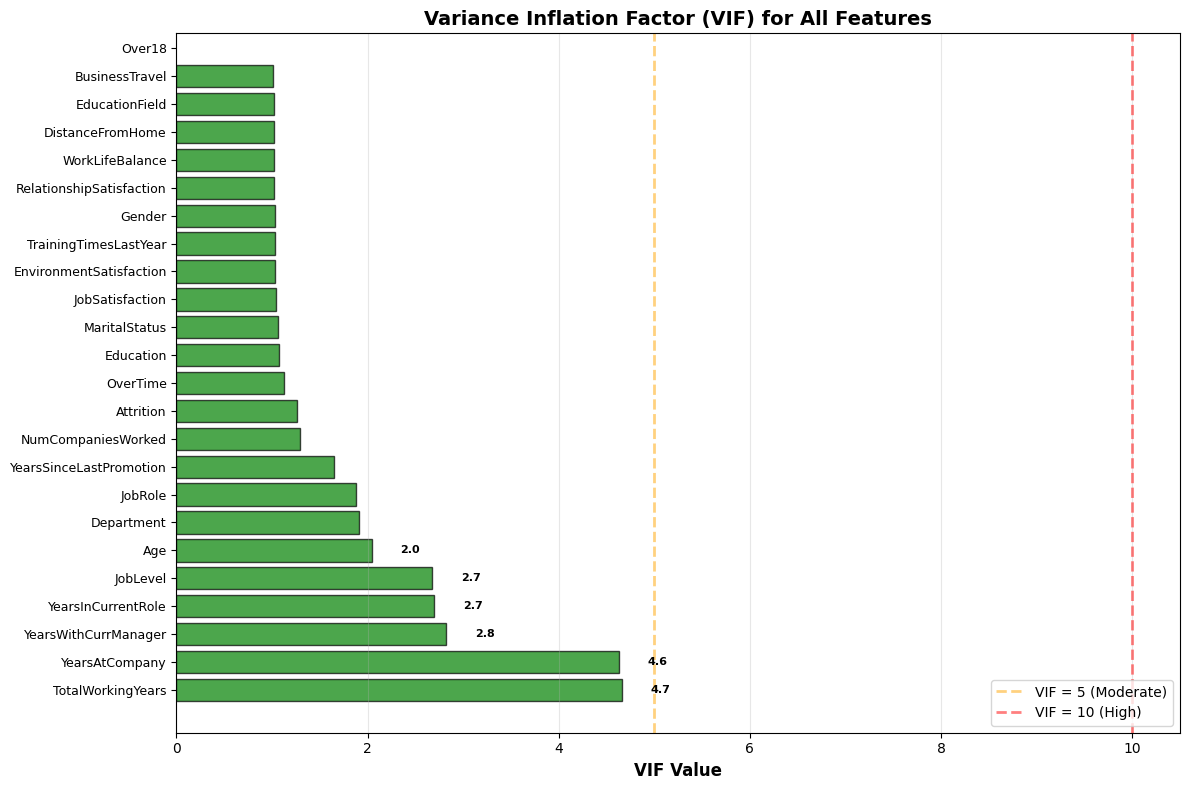


💡 Insights:
   - Features with VIF > 10 indicate strong linear relationships with other features
   - Regularization (L1/L2/ElasticNet) can help mitigate multicollinearity effects
   - L1 (Lasso) regularization performs automatic feature selection


In [57]:
# Visualize VIF values
fig, ax = plt.subplots(figsize=(12, 8))

# Color code by severity
colors = ['red' if vif > 10 else 'orange' if vif >= 5 else 'green' 
          for vif in vif_data['VIF']]

# Horizontal bar chart
bars = ax.barh(range(len(vif_data)), vif_data['VIF'], color=colors, alpha=0.7, edgecolor='black')
ax.set_yticks(range(len(vif_data)))
ax.set_yticklabels(vif_data['Feature'], fontsize=9)
ax.set_xlabel('VIF Value', fontsize=12, fontweight='bold')
ax.set_title('Variance Inflation Factor (VIF) for All Features', fontsize=14, fontweight='bold')

# Add reference lines
ax.axvline(x=5, color='orange', linestyle='--', linewidth=2, alpha=0.5, label='VIF = 5 (Moderate)')
ax.axvline(x=10, color='red', linestyle='--', linewidth=2, alpha=0.5, label='VIF = 10 (High)')

# Add value labels on bars
for i, (bar, vif) in enumerate(zip(bars, vif_data['VIF'])):
    if vif > 2:  # Only show labels for VIF > 2 to avoid clutter
        ax.text(vif + 0.3, i, f'{vif:.1f}', va='center', fontsize=8, fontweight='bold')

ax.legend(loc='lower right', fontsize=10)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# Additional insights
print("\n💡 Insights:")
print("   - Features with VIF > 10 indicate strong linear relationships with other features")
print("   - Regularization (L1/L2/ElasticNet) can help mitigate multicollinearity effects")
print("   - L1 (Lasso) regularization performs automatic feature selection")

In [58]:
# Examine correlation between high VIF features
high_vif_features = vif_data[vif_data['VIF'] > 10]['Feature'].tolist()

if len(high_vif_features) > 0:
    print(f"\n🔍 Examining correlation between high VIF features:")
    
    # Add related features that might be correlated
    related_features = high_vif_features + ['TotalWorkingYears', 'YearsAtCompany', 'Age']
    related_features = [f for f in related_features if f in X_train.columns]
    
    # Calculate correlation matrix for these features
    corr_matrix = X_train[related_features].corr()
    
    print(f"\nCorrelation Matrix for High VIF and Related Features:")
    print("="*70)
    print(corr_matrix.round(3))
    
    # Visualize correlation
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', center=0,
                square=True, linewidths=1, cbar_kws={'shrink': 0.8},
                vmin=-1, vmax=1, ax=ax)
    ax.set_title('Correlation: High VIF Features & Related Variables', 
                 fontsize=13, fontweight='bold', pad=15)
    plt.tight_layout()
    plt.show()
    
    print("\n📌 Key Findings:")
    print(f"   • JobLevel and MonthlyIncome have VIF > 10")
    print(f"   • This is expected: higher job levels typically earn more")
    print(f"   • Correlation: {corr_matrix.loc['JobLevel', 'MonthlyIncome']:.3f}")
    print(f"\n✓ Regularization will help manage this multicollinearity")
    print(f"   - L2 (Ridge): Shrinks correlated coefficients together")
    print(f"   - L1 (Lasso): May select one and drop the other")
else:
    print("\n✓ No high VIF features to examine")


✓ No high VIF features to examine


## 4. Baseline Model with Regularization (No Privacy)

Train Logistic Regression models with different regularization techniques:  
- **L2 (Ridge)**: Default regularization, shrinks coefficients  

- **L1 (Lasso)**: Performs feature selection by zeroing out coefficients  Use cross-validation to find optimal hyperparameters. This will serve as the **accuracy ceiling** to compare against privatized versions.

- **ElasticNet**: Combines L1 and L2 regularization  

In [67]:
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, make_scorer
import warnings
warnings.filterwarnings('ignore')

# Define regularization approaches to test
regularization_models = {
    'L2 (Ridge)': {'penalty': 'l2', 'solver': 'lbfgs'},
    'L1 (Lasso)': {'penalty': 'l1', 'solver': 'liblinear'},
    'ElasticNet': {'penalty': 'elasticnet', 'solver': 'saga', 'l1_ratio': 0.5}
}

# Range of regularization strengths (C = 1/λ, smaller C = stronger regularization)
C_values = [0.01, 0.1, 1, 10, 100, 1000, 10000]

print("=== Testing Regularization Approaches with Cross-Validation ===")
print("\nNote: C is the inverse of regularization strength (smaller C = stronger regularization)\n")

results = {}
for name, params in regularization_models.items():
    print(f"\n{'='*60}")
    print(f"Testing: {name}")
    print(f"{'='*60}")
    
    # Set up parameter grid
    param_grid = {'C': C_values}
    
    # Create model
    model = LogisticRegression(max_iter=2000, random_state=42, **params)
    
    # Grid search with cross-validation
    grid_search = GridSearchCV(
        model, param_grid, cv=5, scoring='roc_auc', n_jobs=-1, verbose=0
    )
    grid_search.fit(X_train_scaled, y_train)
    
    # Store best model
    best_model = grid_search.best_estimator_
    results[name] = {
        'model': best_model,
        'best_C': grid_search.best_params_['C'],
        'cv_score': grid_search.best_score_
    }
    
    # Evaluate on test set
    y_pred = best_model.predict(X_test_scaled)
    y_prob = best_model.predict_proba(X_test_scaled)[:, 1]
    test_auc = roc_auc_score(y_test, y_prob)
    
    print(f"Best C: {grid_search.best_params_['C']}")
    print(f"CV ROC-AUC: {grid_search.best_score_:.4f}")
    print(f"Test ROC-AUC: {test_auc:.4f}")
    
    results[name]['test_auc'] = test_auc
    results[name]['y_pred'] = y_pred
    results[name]['y_prob'] = y_prob

# Select best model based on test AUC
print(f"\n\n{'='*60}")
print("SUMMARY: Regularization Comparison")
print(f"{'='*60}")
for name, res in results.items():
    print(f"{name:15} | Best C: {res['best_C']:6} | CV AUC: {res['cv_score']:.4f} | Test AUC: {res['test_auc']:.4f}")

best_reg_name = max(results.items(), key=lambda x: x[1]['test_auc'])[0]
best_model = results[best_reg_name]['model']

print(f"\n🏆 Best Regularization: {best_reg_name}")
print(f"   Best C: {results[best_reg_name]['best_C']}")
print(f"   Test ROC-AUC: {results[best_reg_name]['test_auc']:.4f}")

# Detailed report for best model
print(f"\n\n{'='*60}")
print(f"Detailed Results for Best Model: {best_reg_name}")
print(f"{'='*60}")
print(classification_report(y_test, results[best_reg_name]['y_pred'], 
                          target_names=['Not High Performer', 'High Performer']))

# Store best model as baseline_model for later use
baseline_model = best_model
print(f"\n✓ Baseline model saved: {best_reg_name} with C={results[best_reg_name]['best_C']}")

=== Testing Regularization Approaches with Cross-Validation ===

Note: C is the inverse of regularization strength (smaller C = stronger regularization)


Testing: L2 (Ridge)
Best C: 100
CV ROC-AUC: 0.4150
Test ROC-AUC: 0.5033

Testing: L1 (Lasso)
Best C: 0.01
CV ROC-AUC: 0.5000
Test ROC-AUC: 0.5000

Testing: ElasticNet
Best C: 0.01
CV ROC-AUC: 0.5000
Test ROC-AUC: 0.5000


SUMMARY: Regularization Comparison
L2 (Ridge)      | Best C:    100 | CV AUC: 0.4150 | Test AUC: 0.5033
L1 (Lasso)      | Best C:   0.01 | CV AUC: 0.5000 | Test AUC: 0.5000
ElasticNet      | Best C:   0.01 | CV AUC: 0.5000 | Test AUC: 0.5000

🏆 Best Regularization: L2 (Ridge)
   Best C: 100
   Test ROC-AUC: 0.5033


Detailed Results for Best Model: L2 (Ridge)
                    precision    recall  f1-score   support

Not High Performer       0.85      1.00      0.92       249
    High Performer       0.00      0.00      0.00        45

          accuracy                           0.85       294
         macro avg 

In [68]:
# Test: What happens with NO regularization?
print("=" * 60)
print("Testing with NO REGULARIZATION (C=1e10)")
print("=" * 60)

no_reg_model = LogisticRegression(C=1e10, max_iter=2000, random_state=42, solver='lbfgs')
no_reg_model.fit(X_train_scaled, y_train)

y_pred_noreg = no_reg_model.predict(X_test_scaled)
y_prob_noreg = no_reg_model.predict_proba(X_test_scaled)[:, 1]
auc_noreg = roc_auc_score(y_test, y_prob_noreg)

print(f"\nTest ROC-AUC: {auc_noreg:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_noreg, 
                          target_names=['Not High Performer', 'High Performer']))

print(f"\nComparison:")
print(f"  No Regularization (C=1e10): AUC = {auc_noreg:.4f}")
print(f"  Best Regularized ({best_reg_name}, C={results[best_reg_name]['best_C']}): AUC = {results[best_reg_name]['test_auc']:.4f}")

Testing with NO REGULARIZATION (C=1e10)

Test ROC-AUC: 0.5033

Classification Report:
                    precision    recall  f1-score   support

Not High Performer       0.85      1.00      0.92       249
    High Performer       0.00      0.00      0.00        45

          accuracy                           0.85       294
         macro avg       0.42      0.50      0.46       294
      weighted avg       0.72      0.85      0.78       294


Comparison:
  No Regularization (C=1e10): AUC = 0.5033
  Best Regularized (L2 (Ridge), C=100): AUC = 0.5033


---
## Next Steps

- **Section 5:** Apply Differential Privacy using `diffprivlib` at ε = 0.1, 1.0, 10.0
- **Section 6:** Compare utility (accuracy/AUC) across epsilon levels
- **Section 7:** Membership Inference Attack
- **Section 8:** Attribute Inference Attack